In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [7]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path

import json
import pandas as pd
import numpy as np

from utils import DATA_DIR
from download.weka import pull_predictions_from_weka

from dataloader import get_nd_array, get_slice

In [3]:
pull_predictions_from_weka("consistent_ranking")

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/all_consistent_ranking_predictions.parquet


In [4]:
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id', 'acc_per_char'] # load a subset of columns to save on memory

df = pd.read_parquet(f'{DATA_DIR}/all_consistent_ranking_predictions.parquet', columns=COLS)

In [129]:
MODELS = df.index.get_level_values('model').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
SIZES  = df['size'].unique()
TOKEN_RATIO = df['token_ratio'].unique()

TASKS = [t for t in TASKS if 'mmlu' not in t]
TASKS = sorted(TASKS)

### Significance Comparison

In [ ]:
# TODO: 
    # Create rejection simulator (i.e., a rule for rejecting mixes and a final score of the number of desired mixes remaining at 1B scale, along with the cumulative compute)
    # Calculate SPA (we can interpret whether we "trust" the stat sig results by looking at SPA and the rejection metric)

In [131]:
SIZES

array(['150M', '530M', '750M', '300M', '1B'], dtype=object)

In [146]:
from stats import compute_significance

models = [model for model in MODELS if '300M' in model]

Computing pairwise comparisons:   0%|          | 0/2 [00:00<?, ?it/s]

Computing pairwise comparisons: 100%|██████████| 2/2 [00:01<00:00,  1.23it/s]


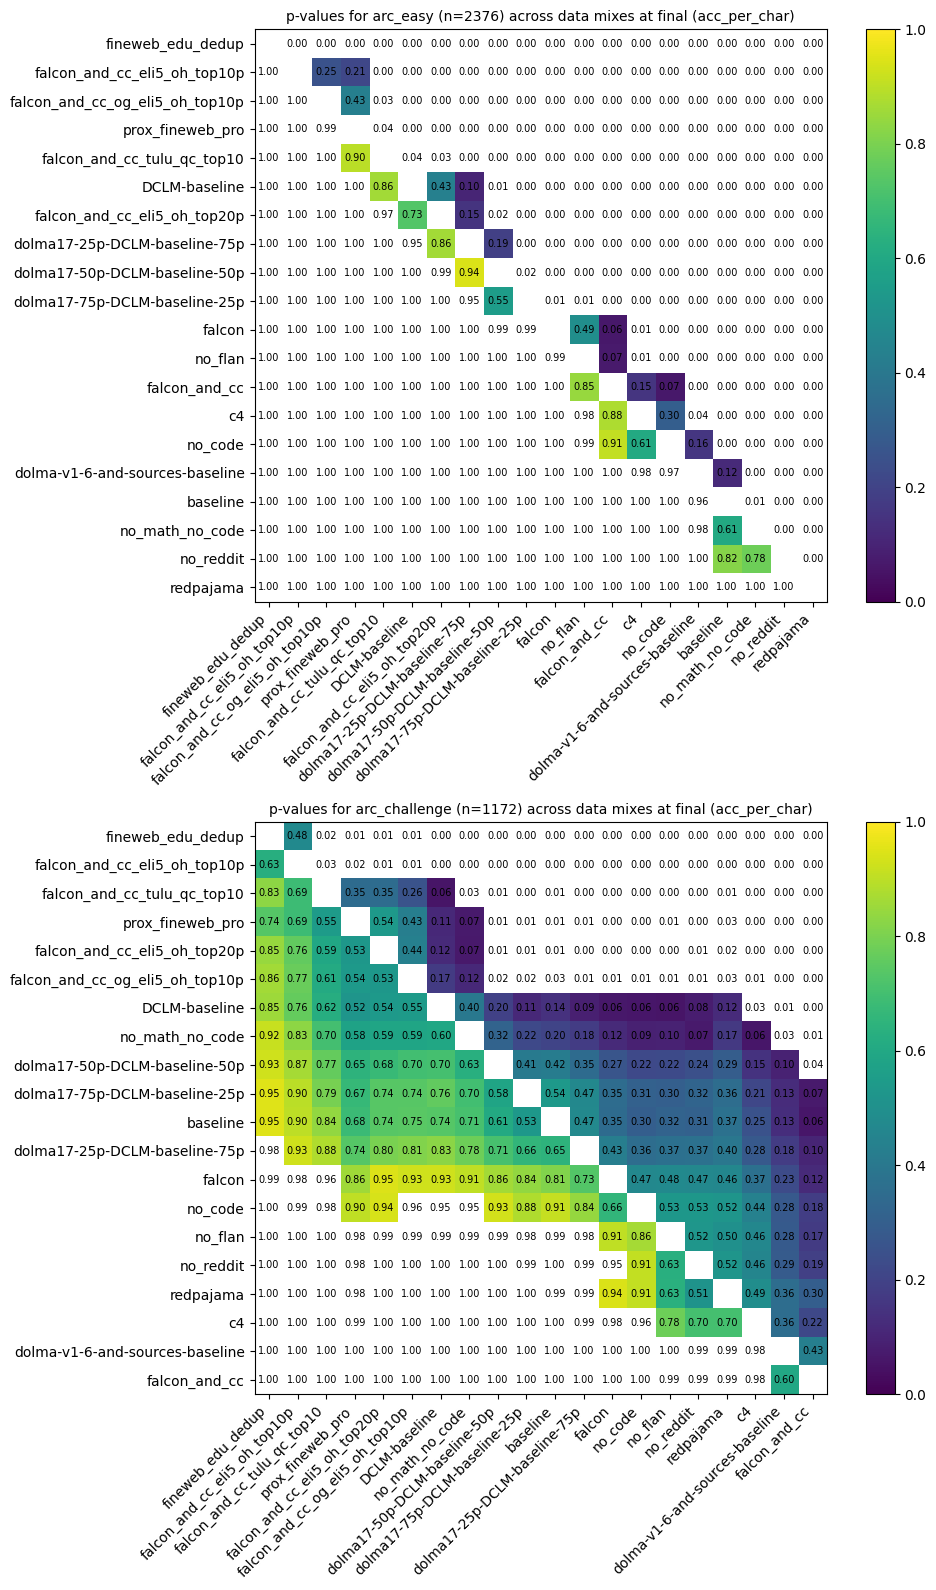

In [136]:
_, _ = compute_significance(df, models, 'acc_per_char', tasks=['arc_easy', 'arc_challenge'], do_plot=True)

Computing pairwise comparisons: 100%|██████████| 4/4 [00:04<00:00,  1.15s/it]


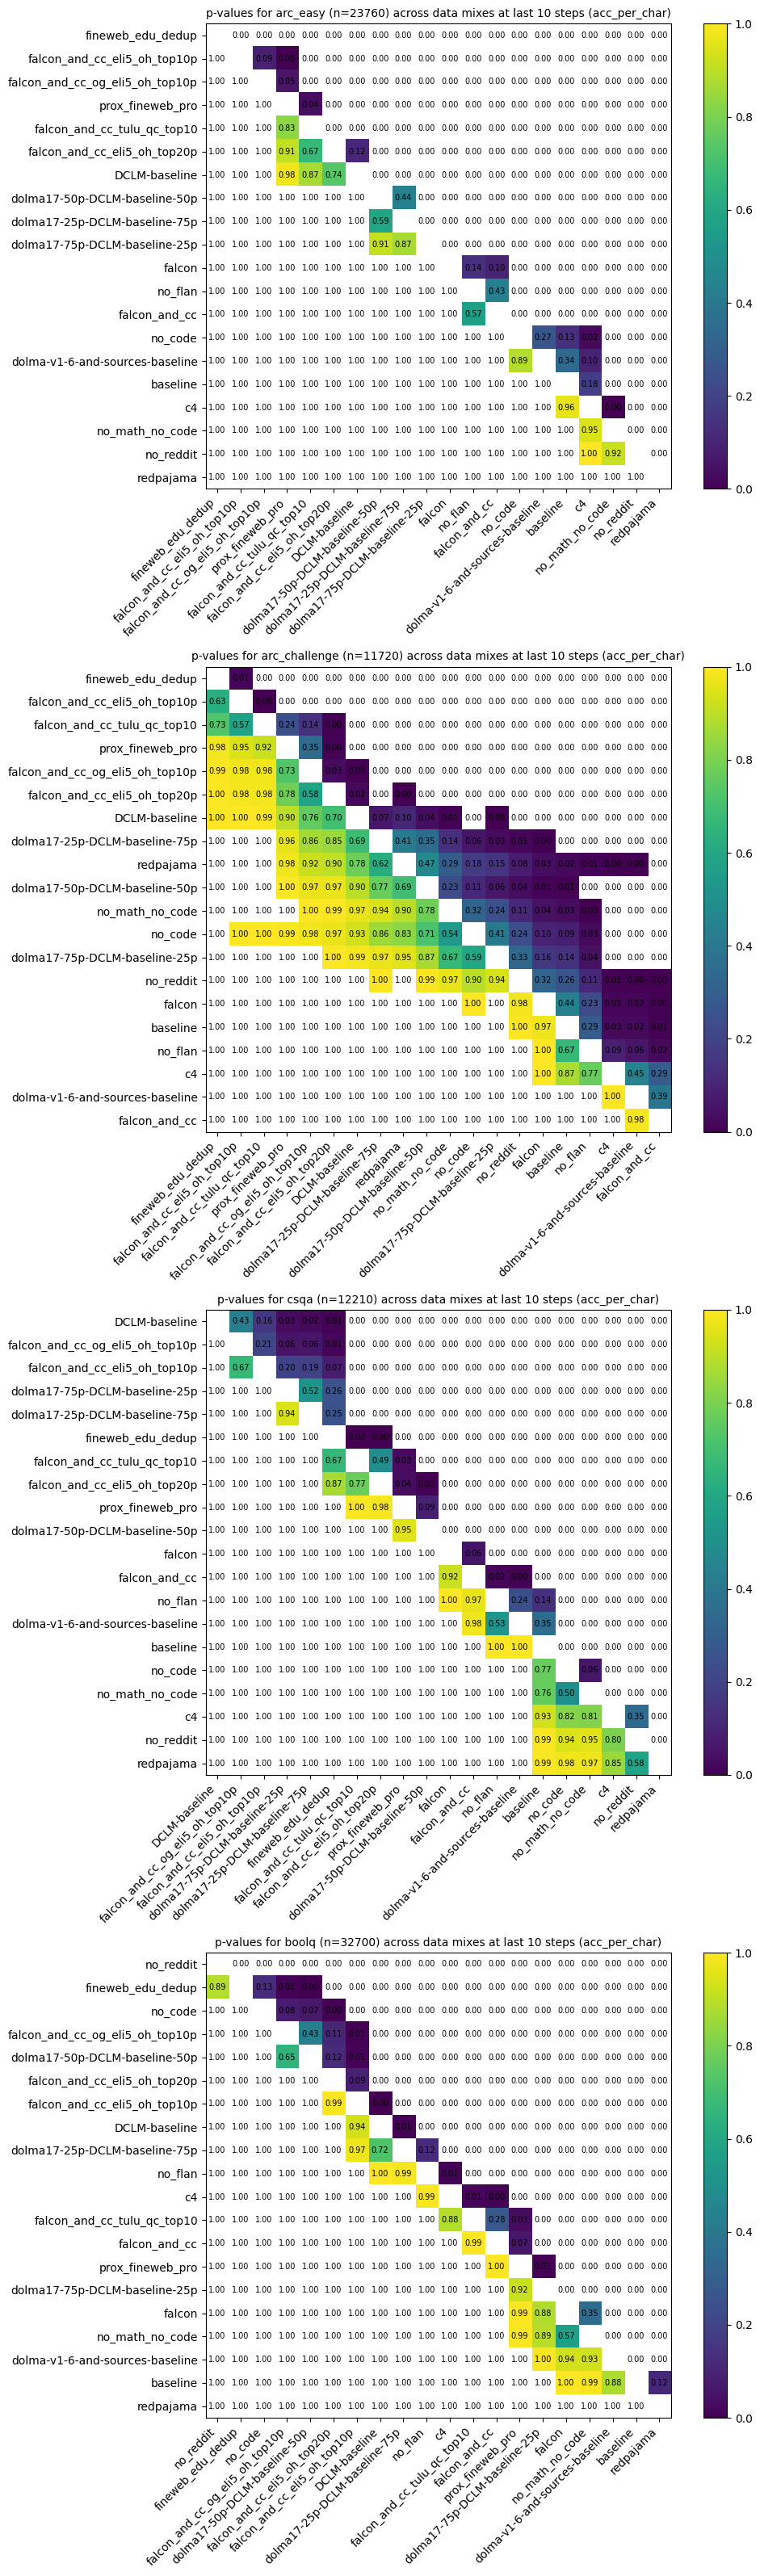

In [147]:
_, _ = compute_significance(df, models, 'acc_per_char', last_n=10, alpha=0.001, tasks=['arc_easy', 'arc_challenge', 'csqa', 'boolq'], do_plot=True)

Computing pairwise comparisons: 100%|██████████| 4/4 [00:06<00:00,  1.53s/it]


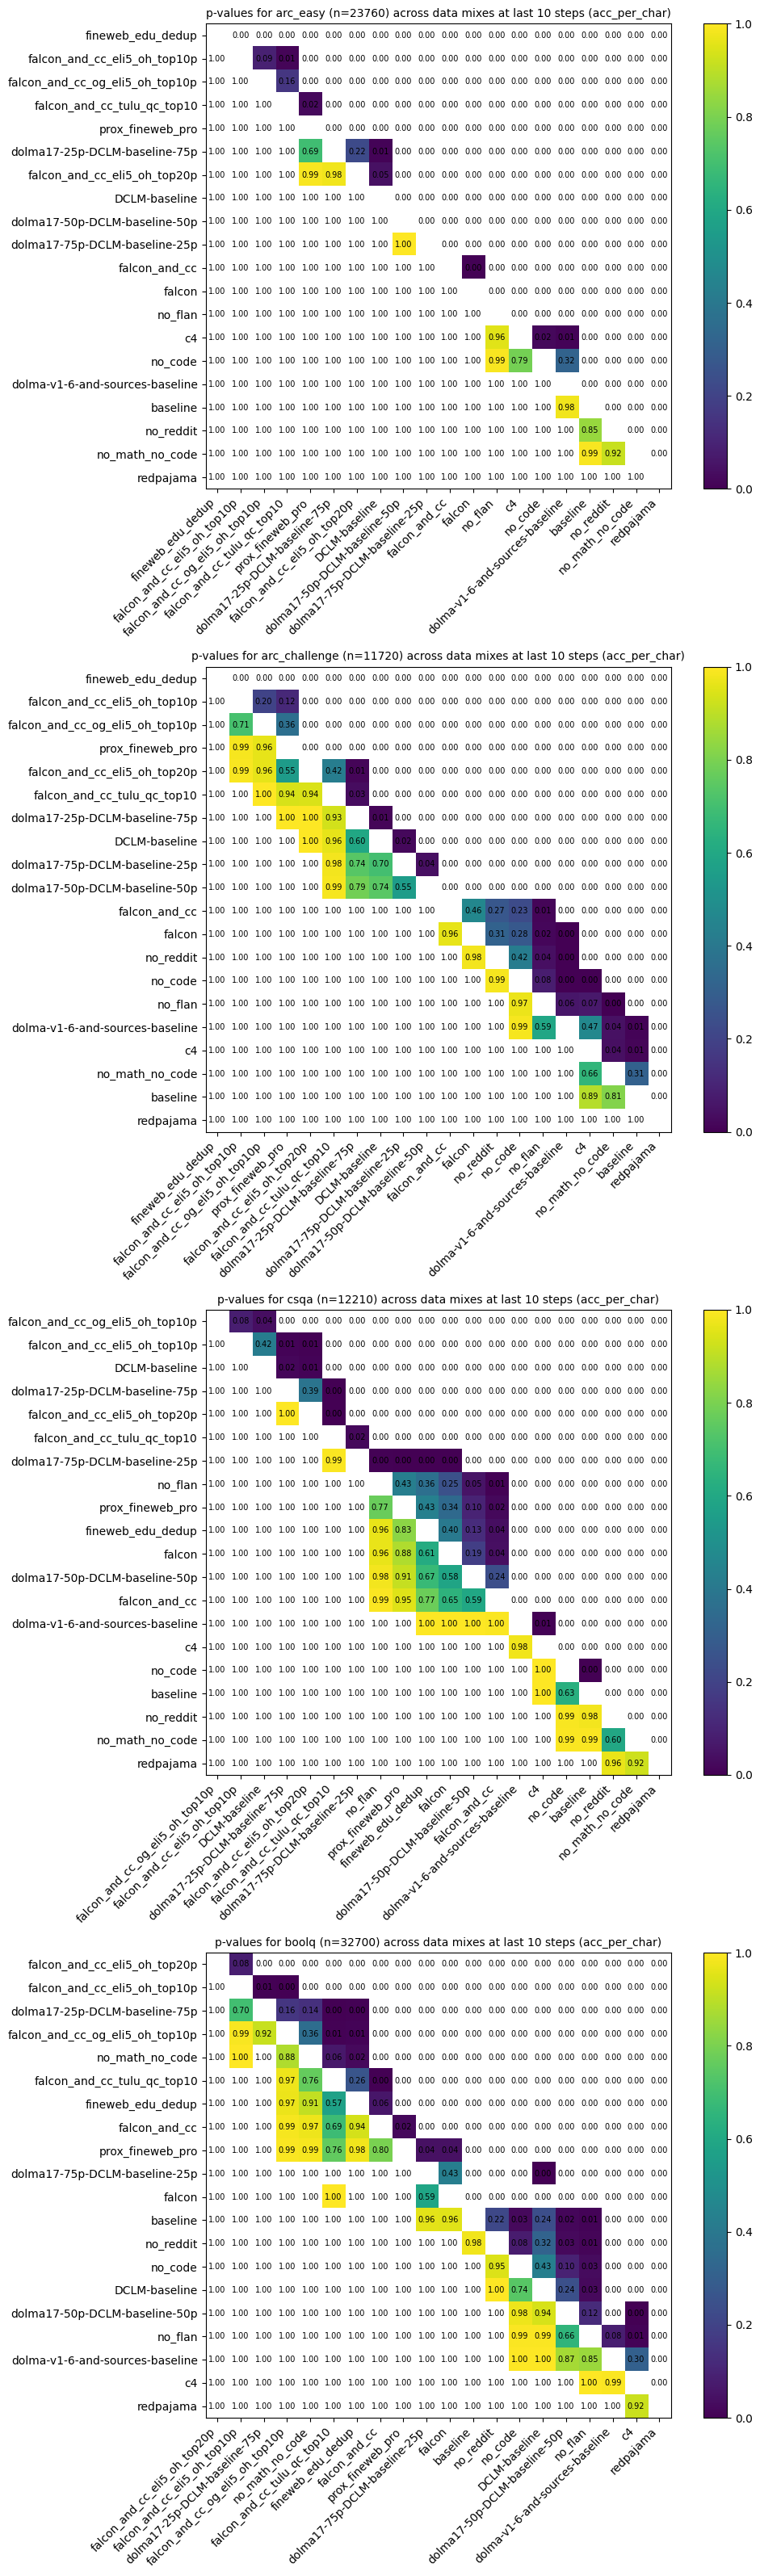

In [148]:
models = [model for model in MODELS if '1B' in model]

_, _ = compute_significance(df, models, 'acc_per_char', last_n=10, alpha=0.001, tasks=['arc_easy', 'arc_challenge', 'csqa', 'boolq'], do_plot=True)